<a href="https://colab.research.google.com/github/Alok224/Celebal_Weekly_Assignments/blob/main/Week6_Alok_Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Denoising using Autoencoder on MNIST

**Objective:** Build a Deep Learning Autoencoder that learns to remove artificial noise from handwritten digit images and reconstruct the clean version.

An autoencoder is a neural network that learns to compress an input into a smaller latent representation (encoder) and then reconstruct it back (decoder). For denoising, we train the autoencoder by giving it a **noisy** image as input but asking it to output the **clean** image. Over time, the network learns to ignore the noise pattern and recover the original digit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

(x_train, _), (x_test, _) = mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


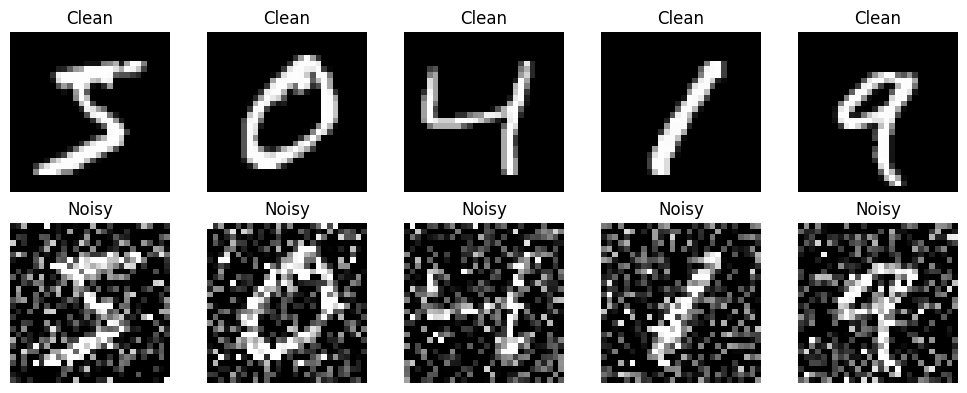

In [2]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Building the Autoencoder

A simple fully-connected autoencoder is used here. The 28x28 image is flattened into a 784-length vector, compressed down to a small latent vector by the encoder, and then the decoder expands it back to 784 values which are reshaped into a 28x28 image.

In [3]:
input_img = Input(shape=(28, 28))

# Encoder
x = Flatten()(input_img)
x = Dense(128, activation="relu")(x)
latent = Dense(64, activation="relu")(x)

# Decoder
x = Dense(128, activation="relu")(latent)
x = Dense(784, activation="sigmoid")(x)
output_img = Reshape((28, 28))(x)

autoencoder = Model(input_img, output_img)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=18,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0613 - val_loss: 0.0377
Epoch 2/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0315 - val_loss: 0.0266
Epoch 3/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0247 - val_loss: 0.0225
Epoch 4/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0216 - val_loss: 0.0204
Epoch 5/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0200 - val_loss: 0.0190
Epoch 6/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0188 - val_loss: 0.0180
Epoch 7/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0179 - val_loss: 0.0172
Epoch 8/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0171 - val_loss: 0.0165
Epoch 9/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0166 - val_loss: 0.0162
Epoch 10/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0162 - val_loss: 0.0158
Epoch 11/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0158 - val_loss: 0.0154
Epoch 12/18
235/235 ━━━━━━━━━━━━━━━━━━━━ 

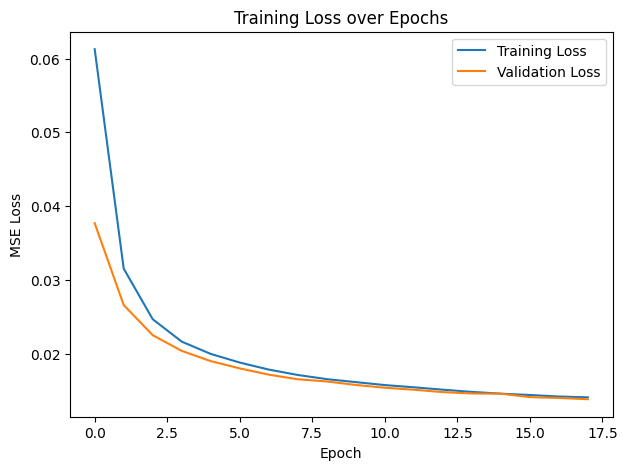

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss over Epochs")
plt.legend()
plt.show()

In [6]:
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


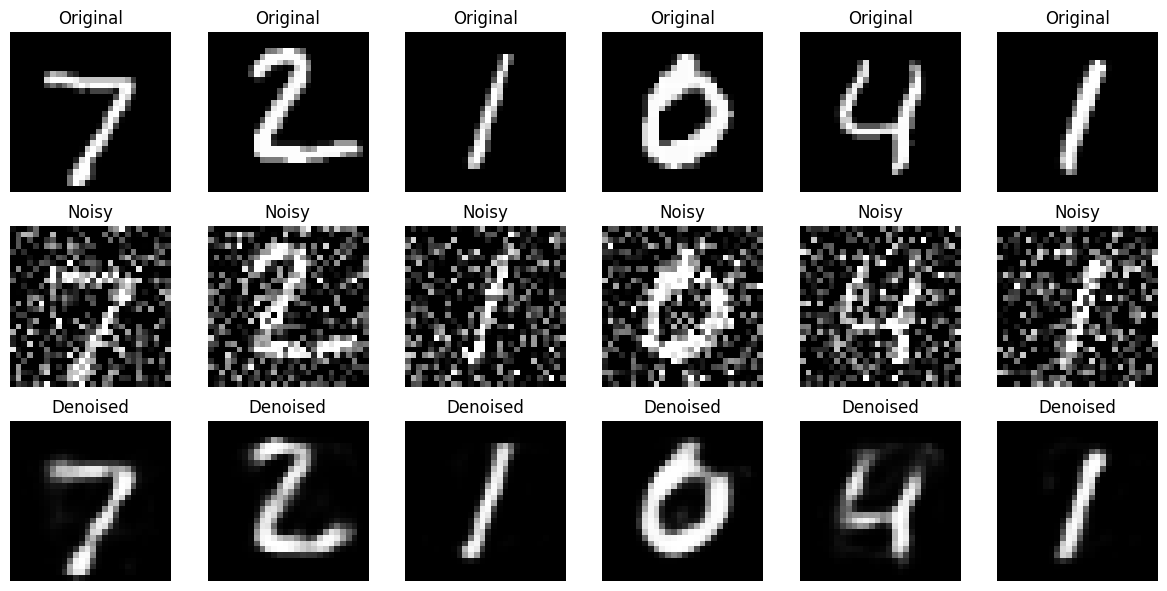

In [7]:
n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i], cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i], cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

- The autoencoder was able to remove a good amount of Gaussian noise from the test images, and the denoised digits are visually much cleaner than the noisy inputs.
- The reconstructed images are slightly blurry compared to the original clean images. This is expected since the network compresses the image into a small latent vector, which causes some loss of fine detail.
- A few digits with heavy noise or unusual handwriting style (e.g. 4s and 9s, or 3s and 8s) are sometimes reconstructed with slightly incorrect strokes, since the model can confuse visually similar digit shapes.

## Conclusion

- The autoencoder learned to map noisy digit images back to their clean form by learning a compressed latent representation that captures the essential shape of each digit while ignoring random pixel noise.
- **Advantages:** Denoising autoencoders are simple to implement, do not need labelled data (only clean/noisy pairs), and can be useful as a pre-processing step before tasks like classification.
- **Limitations:** The reconstructed images can be slightly blurry, and the model is trained for one type and level of noise, so it may not generalize well to very different noise patterns.
- **Future improvements:** Using convolutional layers instead of fully-connected ones could preserve spatial details better, and training on multiple noise types/levels could make the model more robust.